# Trajectory Inference Tests

Test the new simulation-based trajectory inference for various pulse sequences.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt
import lmt_sim.lmt_simulation as sim
import lmt_sim.lmt_sequence as seq
from scipy import constants as scipy_constants
import version_info as vs

from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.ticker import FixedLocator


In [2]:
CLOCK_SHELVING_PULSE_TIME = 380e-6
SHELVING_PULSE_CLEAROUT_DURATION = 2200e-6
LMT_SELECTIVE_PI_TIME = 95e-6
LMT_PULSE_CLEAROUT_DURATION = 50e-6
GRAVITY_DOPPLER_PER_SEC_HZ = (
    sim.TRANSITION_FREQUENCY * scipy_constants.g / scipy_constants.c
)


def insert_clearouts_preserving_pulse_timing(sequence, placements):
    sequence = list(sequence)
    for mode, pulse_index, clearout_duration, label in reversed(placements):
        if mode == "after":
            freefall_index = pulse_index + 1
            if freefall_index >= len(sequence) or not isinstance(
                sequence[freefall_index], seq.Freefall
            ):
                raise ValueError(
                    f"Cannot insert {label} after pulse index {pulse_index}: expected a following Freefall"
                )
            freefall = sequence[freefall_index]
            if freefall.duration < clearout_duration:
                raise ValueError(
                    f"Cannot insert {label}: following Freefall is shorter than {clearout_duration * 1e6:.1f} us"
                )

            replacement = [seq.Clearout(duration=clearout_duration, label=label)]
            remaining_duration = freefall.duration - clearout_duration
            if remaining_duration > 0.0:
                replacement.append(
                    seq.Freefall(duration=remaining_duration, label=freefall.label)
                )
            sequence[freefall_index : freefall_index + 1] = replacement
        elif mode == "before":
            freefall_index = pulse_index - 1
            if freefall_index < 0 or not isinstance(
                sequence[freefall_index], seq.Freefall
            ):
                raise ValueError(
                    f"Cannot insert {label} before pulse index {pulse_index}: expected a preceding Freefall"
                )
            freefall = sequence[freefall_index]
            if freefall.duration < clearout_duration:
                raise ValueError(
                    f"Cannot insert {label}: preceding Freefall is shorter than {clearout_duration * 1e6:.1f} us"
                )

            replacement = []
            remaining_duration = freefall.duration - clearout_duration
            if remaining_duration > 0.0:
                replacement.append(
                    seq.Freefall(duration=remaining_duration, label=freefall.label)
                )
            replacement.append(seq.Clearout(duration=clearout_duration, label=label))
            sequence[freefall_index : freefall_index + 1] = replacement
        else:
            raise ValueError(f"Unsupported clearout placement mode: {mode!r}")

    return sequence


def add_true_lmt_clearouts(sequence, duration_tolerance=1e-6):
    if any(isinstance(event, seq.Clearout) for event in sequence):
        raise ValueError("Sequence already contains Clearout events")

    velocity_selection_indices = [
        i
        for i, event in enumerate(sequence)
        if isinstance(event, seq.Pulse)
        and np.isclose(
            event.duration,
            CLOCK_SHELVING_PULSE_TIME,
            atol=duration_tolerance,
            rtol=0.0,
        )
    ]
    if len(velocity_selection_indices) != 1:
        raise ValueError(
            f"Expected exactly one velocity-selection pulse in extracted sequence, found {len(velocity_selection_indices)}"
        )

    selective_indices = [
        i
        for i, event in enumerate(sequence)
        if isinstance(event, seq.Pulse)
        and np.isclose(
            event.duration,
            LMT_SELECTIVE_PI_TIME,
            atol=duration_tolerance,
            rtol=0.0,
        )
    ]
    if len(selective_indices) != 4:
        raise ValueError(
            "Expected exactly four selective 95 us pulses in extracted sequence"
        )

    placements = [
        (
            "after",
            velocity_selection_indices[0],
            SHELVING_PULSE_CLEAROUT_DURATION,
            "vs_clearout",
        ),
        (
            "after",
            selective_indices[0],
            LMT_PULSE_CLEAROUT_DURATION,
            "clearout_after_first_sel_upper",
        ),
        (
            "before",
            selective_indices[1],
            LMT_PULSE_CLEAROUT_DURATION,
            "clearout_before_last_sel_upper",
        ),
        (
            "after",
            selective_indices[2],
            LMT_PULSE_CLEAROUT_DURATION,
            "clearout_after_first_sel_lower",
        ),
        (
            "before",
            selective_indices[3],
            LMT_PULSE_CLEAROUT_DURATION,
            "clearout_before_last_sel_lower",
        ),
    ]
    return insert_clearouts_preserving_pulse_timing(sequence, placements)


def build_sequence_from_lab_pulse_dump(
    is_up,
    start_times_mu,
    durations_mu,
    opll_hz,
    beam_hz,
    *,
    pi_pulse_threshold_s=50e-6,
):
    if pi_pulse_threshold_s <= 0.0:
        raise ValueError("pi_pulse_threshold_s must be positive")

    is_up = np.asarray(is_up, dtype=bool)
    start_times_mu = np.asarray(start_times_mu, dtype=float)
    durations_mu = np.asarray(durations_mu, dtype=float)
    opll_hz = np.asarray(opll_hz, dtype=float)
    beam_hz = np.asarray(beam_hz, dtype=float)

    lengths = {
        len(is_up),
        len(start_times_mu),
        len(durations_mu),
        len(opll_hz),
        len(beam_hz),
    }
    if len(lengths) != 1:
        raise ValueError("Lab pulse dump arrays must all have the same length")

    timestamps = start_times_mu * 1e-9
    durations = durations_mu * 1e-9
    total_laser_frequency_hz = opll_hz + beam_hz

    beam_sign = np.where(is_up, 1.0, -1.0)
    total_laser_frequency_hz = (
        total_laser_frequency_hz - GRAVITY_DOPPLER_PER_SEC_HZ * timestamps * beam_sign
    )

    centre_freq_hz = total_laser_frequency_hz[0] - sim.RECOIL_FREQUENCY_HZ

    sequence = []
    t_now = 0.0

    for this_is_up, this_timestamp, this_duration, this_total_laser_hz in zip(
        is_up,
        timestamps,
        durations,
        total_laser_frequency_hz,
    ):
        if this_timestamp < t_now:
            raise ValueError(
                f"Pulse timestamps must be non-decreasing. Got {this_timestamp} < {t_now}."
            )
        if this_timestamp > t_now:
            sequence.append(seq.Freefall(duration=this_timestamp - t_now))
            t_now = this_timestamp

        if this_duration > pi_pulse_threshold_s:
            rabi_freq_hz = 1 / (2 * this_duration)
        else:
            rabi_freq_hz = 1 / (4 * this_duration)

        # Probe-induced (AC-Stark) shift coefficient alpha: each pulse's
        # resonance is shifted by alpha * rabi_frequency**2 Hz. Inferred from the
        # measured up-beam recoil ladder (380 us pi velocity-selection, 95 us pi,
        # 55 us pi mirrors). Differencing the pulse detunings cancels the unknown
        # unperturbed transition frequency; the long-baseline (380 us, 55 us) pair
        # gives alpha ~ -1.9e-5 Hz^-1, with the (95 us, 55 us) and (380 us, 95 us)
        # pairs bracketing it at -1.3e-5 and -3.3e-5.
        probe_induced_shift_coefficient = -1.9e-5

        sequence.append(
            seq.Pulse(
                k=+1 if this_is_up else -1,
                detuning_hz=this_total_laser_hz - centre_freq_hz,
                phi=0.0,
                label="LMT",
                rabi_frequency=rabi_freq_hz,
                duration=this_duration,
                probe_shift_coefficient=probe_induced_shift_coefficient
            )
        )
        t_now += this_duration
 
    return sequence, total_laser_frequency_hz

In [3]:
pulse_sequence = [[[1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0], [4936, 2690399, 2783176, 2984024, 3112024, 3227024, 3355024, 3470024, 3598024, 3713024, 3841024, 3956024, 4084024, 4199024, 4327024, 4442024, 4570024, 6837288, 6965288, 7080288, 7208288, 7323288, 7451288, 7566288, 7694288, 7809288, 7937288, 8052288, 8180288, 8295288, 8423288, 8547087, 8649903, 8680418, 8872208, 9223048, 9351048, 9466048, 9594048, 9709048, 9837048, 9952048, 10080048, 10195048, 10323048, 10438048, 10566048, 10681048, 10809048, 10924048, 11052048, 11167048, 11295048, 11410048, 11538048, 11653048, 11781048, 11896048, 12024048, 12139048, 12267048, 12382048, 12510048, 12625048, 12753048, 12868048, 12996048, 13111048, 13239048, 13354048, 13482048, 13597048, 13725048, 13840048, 14018055, 14146055, 14261055, 14389055, 14504055, 14632055, 14747055, 14875055, 14990055, 15118055, 15233055, 15361055, 15476055, 15604055, 15719055, 15847055, 15962055, 16090055, 16205055, 16333055, 16448055, 16576055, 16691055, 16819055, 16934055, 17062055, 17177055, 17305055, 17420055, 17548055, 17663055, 17791055, 17906055, 18034055, 18149055, 18277055, 18392055, 18520055, 18635055, 18970856, 19121688, 19296216, 19647056, 19775056, 19890056, 20018056, 20133056, 20261056, 20376056, 20504056, 20619056, 20747056, 20862056, 20990056, 21105056, 21233056, 21348056, 21476056, 21591056, 21719056, 21834056, 21962056, 22077056, 22205056, 22320056, 22448056, 22563056, 22691056, 22806056, 22934056, 23049056, 23177056, 23292056, 23420056, 23535056, 23663056, 23778056, 23906056, 24021056, 24149056, 24264056, 24442064, 24570064, 24685064, 24813064, 24928064, 25056064, 25171064, 25299064, 25414064, 25542064, 25657064, 25785064, 25900064, 26028064, 26143064, 26271064, 26386064, 26514064, 26629064, 26757064, 26872064, 27000064, 27115064, 27243064, 27358064, 27486064, 27601064, 27729064, 27844064, 27972064, 28087064, 28215064, 28330064, 28458064, 28573064, 28701064, 28816064, 28944064, 29059064, 29394864, 29599368], [380000, 34000, 95000, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 95000, 27499, 34000, 94999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 94999, 68000, 94999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 94999, 34000], [80000000, 79972625, 80020575, 79987302, 80006094, 80002690, 79990706, 80018078, 79975318, 80033466, 79959930, 80048855, 79944542, 80064243, 79929154, 80079631, 79913765, 79913600, 80078997, 79928988, 80063608, 79944376, 80048220, 79959764, 80032832, 79975152, 80017444, 79990540, 80002056, 80005928, 79986668, 80024895, 79974050, 80094321, 79899769, 80105702, 79886894, 80121090, 79871506, 80136478, 79856118, 80151866, 79840730, 80167254, 79825342, 80182643, 79809954, 80198031, 79794566, 80213419, 79779177, 80228807, 79763789, 80244195, 79748401, 80259583, 79733013, 80274971, 79717625, 80290359, 79702237, 80305748, 79686849, 80321136, 79671461, 80336524, 79656072, 80351912, 79640684, 80367300, 79625296, 80382688, 79609908, 80398076, 80395377, 79615819, 80373165, 79638031, 80350953, 79660243, 80328741, 79682455, 80306529, 79704667, 80284317, 79726879, 80262106, 79749091, 80239894, 79771303, 80217682, 79793514, 80195470, 79815726, 80173258, 79837938, 80151046, 79860150, 80128834, 79882362, 80106622, 79904574, 80084410, 79926786, 80062199, 79948998, 80039987, 79971209, 80017775, 79993421, 79995563, 80015633, 79973351, 80041361, 79947518, 80045929, 79959142, 80033254, 79974530, 80017866, 79989918, 80002478, 80005306, 79987090, 80020694, 79971702, 80036082, 79956314, 80051471, 79940926, 80066859, 79925538, 80082247, 79910149, 80097635, 79894761, 80113023, 79879373, 80128411, 79863985, 80143799, 79848597, 80159187, 79833209, 80174576, 79817821, 80189964, 79802433, 80205352, 79787044, 80220740, 79771656, 80236128, 79756268, 80251516, 80249017, 79762179, 80226805, 79784391, 80204593, 79806603, 80182381, 79828815, 80160169, 79851027, 80137957, 79873239, 80115745, 79895451, 80093534, 79917663, 80071322, 79939875, 80049110, 79962086, 80026898, 79984298, 80004686, 80006510, 79982474, 80028722, 79960262, 80050934, 79938050, 80073146, 79915838, 80095358, 79893627, 80117570, 79871415, 80139782, 79849203, 80161993, 79826991, 80186721, 79800435], [200000000, 200005800, 200000500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200000500, 200005800, 200000500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200000500, 200005800, 200000500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200000500, 200005800]], [[1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0], [4936, 2690399, 2783176, 2984024, 3112024, 3227024, 3355024, 3470024, 3598024, 3713024, 3841024, 3956024, 4084024, 4199024, 4327024, 4442024, 4570024, 6837288, 6965288, 7080288, 7208288, 7323288, 7451288, 7566288, 7694288, 7809288, 7937288, 8052288, 8180288, 8295288, 8423288, 8547087, 8649903, 8680418, 8872208, 9223048, 9351048, 9466048, 9594048, 9709048, 9837048, 9952048, 10080048, 10195048, 10323048, 10438048, 10566048, 10681048, 10809048, 10924048, 11052048, 11167048, 11295048, 11410048, 11538048, 11653048, 11781048, 11896048, 12024048, 12139048, 12267048, 12382048, 12510048, 12625048, 12753048, 12868048, 12996048, 13111048, 13239048, 13354048, 13482048, 13597048, 13725048, 13840048, 14018055, 14146055, 14261055, 14389055, 14504055, 14632055, 14747055, 14875055, 14990055, 15118055, 15233055, 15361055, 15476055, 15604055, 15719055, 15847055, 15962055, 16090055, 16205055, 16333055, 16448055, 16576055, 16691055, 16819055, 16934055, 17062055, 17177055, 17305055, 17420055, 17548055, 17663055, 17791055, 17906055, 18034055, 18149055, 18277055, 18392055, 18520055, 18635055, 18970856, 19121688, 19296216, 19647056, 19775056, 19890056, 20018056, 20133056, 20261056, 20376056, 20504056, 20619056, 20747056, 20862056, 20990056, 21105056, 21233056, 21348056, 21476056, 21591056, 21719056, 21834056, 21962056, 22077056, 22205056, 22320056, 22448056, 22563056, 22691056, 22806056, 22934056, 23049056, 23177056, 23292056, 23420056, 23535056, 23663056, 23778056, 23906056, 24021056, 24149056, 24264056, 24442064, 24570064, 24685064, 24813064, 24928064, 25056064, 25171064, 25299064, 25414064, 25542064, 25657064, 25785064, 25900064, 26028064, 26143064, 26271064, 26386064, 26514064, 26629064, 26757064, 26872064, 27000064, 27115064, 27243064, 27358064, 27486064, 27601064, 27729064, 27844064, 27972064, 28087064, 28215064, 28330064, 28458064, 28573064, 28701064, 28816064, 28944064, 29059064, 29394864, 29599368], [380000, 34000, 95000, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 95000, 27499, 34000, 94999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 94999, 68000, 94999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 94999, 34000], [80000000, 79972625, 80020575, 79987302, 80006094, 80002690, 79990706, 80018078, 79975318, 80033466, 79959930, 80048855, 79944542, 80064243, 79929154, 80079631, 79913765, 79913600, 80078997, 79928988, 80063608, 79944376, 80048220, 79959764, 80032832, 79975152, 80017444, 79990540, 80002056, 80005928, 79986668, 80024895, 79974050, 80094321, 79899769, 80105702, 79886894, 80121090, 79871506, 80136478, 79856118, 80151866, 79840730, 80167254, 79825342, 80182643, 79809954, 80198031, 79794566, 80213419, 79779177, 80228807, 79763789, 80244195, 79748401, 80259583, 79733013, 80274971, 79717625, 80290359, 79702237, 80305748, 79686849, 80321136, 79671461, 80336524, 79656072, 80351912, 79640684, 80367300, 79625296, 80382688, 79609908, 80398076, 80395377, 79615819, 80373165, 79638031, 80350953, 79660243, 80328741, 79682455, 80306529, 79704667, 80284317, 79726879, 80262106, 79749091, 80239894, 79771303, 80217682, 79793514, 80195470, 79815726, 80173258, 79837938, 80151046, 79860150, 80128834, 79882362, 80106622, 79904574, 80084410, 79926786, 80062199, 79948998, 80039987, 79971209, 80017775, 79993421, 79995563, 80015633, 79973351, 80041361, 79947518, 80045929, 79959142, 80033254, 79974530, 80017866, 79989918, 80002478, 80005306, 79987090, 80020694, 79971702, 80036082, 79956314, 80051471, 79940926, 80066859, 79925538, 80082247, 79910149, 80097635, 79894761, 80113023, 79879373, 80128411, 79863985, 80143799, 79848597, 80159187, 79833209, 80174576, 79817821, 80189964, 79802433, 80205352, 79787044, 80220740, 79771656, 80236128, 79756268, 80251516, 80249017, 79762179, 80226805, 79784391, 80204593, 79806603, 80182381, 79828815, 80160169, 79851027, 80137957, 79873239, 80115745, 79895451, 80093534, 79917663, 80071322, 79939875, 80049110, 79962086, 80026898, 79984298, 80004686, 80006510, 79982474, 80028722, 79960262, 80050934, 79938050, 80073146, 79915838, 80095358, 79893627, 80117570, 79871415, 80139782, 79849203, 80161993, 79826991, 80186721, 79800435], [200000500, 200005800, 200000500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200000500, 200005800, 200000500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200000500, 200005800, 200000500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200000500, 200005800]], [[-1]], [[-1]], [[-1]], [[-1]], [[-1]], [[-1]], [[-1]], [[-1]], [[-1]], [[-1]], [[-1]], [[-1]], [[-1]], [[-1]], [[-1]], [[-1]], [[-1]], [[-1]], [[-1]], [[-1]], [[-1]], [[-1]], [[-1]], [[-1]], [[-1]], [[-1]]]

In [4]:
(
    is_up,
    start_times_mu,
    durations_mu,
    opll_hz,
    beam_hz,
) = pulse_sequence[0]

is_up = np.array(is_up)
start_times_mu = np.array(start_times_mu)
durations_mu = np.array(durations_mu)
opll_hz = np.array(opll_hz)
beam_hz = np.array(beam_hz)

In [5]:
# Manually specify which durations are pi pulses and which are pi/2
is_pi_pulse = lambda d: d > 50000e-9

In [6]:
sequence, sequence_laser_hz = build_sequence_from_lab_pulse_dump(
    is_up=is_up,
    start_times_mu=start_times_mu,
    durations_mu=durations_mu,
    opll_hz=opll_hz,
    beam_hz=beam_hz,
)

# Skip the first freefall
sequence = sequence[1:]

In [7]:
# sequence = add_true_lmt_clearouts(sequence)

In [8]:
# sequence = sequence[:15]
sequence

[Pulse(k=1, detuning_hz=np.float64(4707.028607964516), phi=0.0, label='LMT', rabi_frequency=np.float64(1315.7894736842104), duration=np.float64(0.00038), beam_waist=1000000.0, probe_shift_coefficient=-1.9e-05),
 Freefall(duration=np.float64(0.002305463), label='freefall'),
 Pulse(k=-1, detuning_hz=np.float64(21000.51998013258), phi=0.0, label='LMT', rabi_frequency=np.float64(7352.941176470588), duration=np.float64(3.4e-05), beam_waist=1000000.0, probe_shift_coefficient=-1.9e-05),
 Freefall(duration=np.float64(5.8776999999999874e-05), label='freefall'),
 Pulse(k=1, detuning_hz=np.float64(-13251.248320400715), phi=0.0, label='LMT', rabi_frequency=np.float64(5263.157894736842), duration=np.float64(9.5e-05), beam_waist=1000000.0, probe_shift_coefficient=-1.9e-05),
 Freefall(duration=np.float64(0.00010584799999999997), label='freefall'),
 Pulse(k=-1, detuning_hz=np.float64(39802.84606355429), phi=0.0, label='LMT', rabi_frequency=np.float64(7352.941176470588), duration=np.float64(6.8e-05), b

In [9]:
sim.RECOIL_FREQUENCY_HZ * 2

9414.057215942552

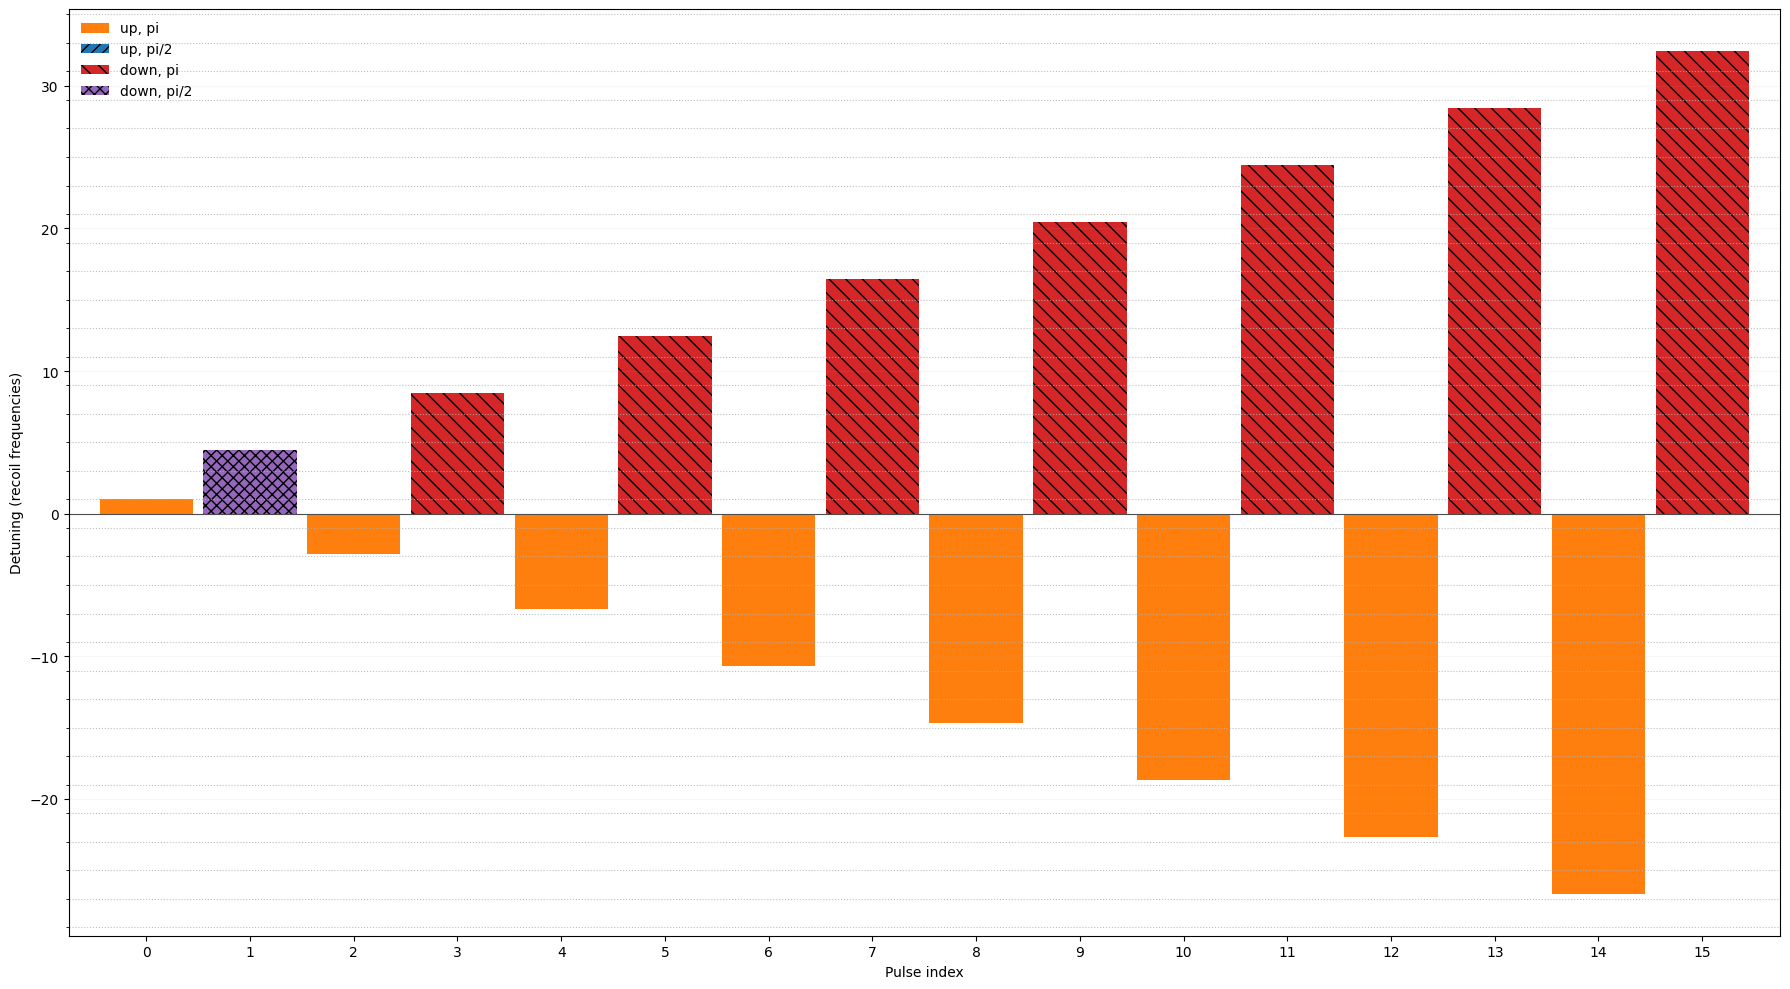

In [10]:

from matplotlib.lines import Line2D
from matplotlib.patches import Patch

plot_sequence, _ = build_sequence_from_lab_pulse_dump(
    is_up=is_up,
    start_times_mu=start_times_mu,
    durations_mu=durations_mu,
    opll_hz=opll_hz,
    beam_hz=beam_hz,
)
# plot_sequence = add_true_lmt_clearouts(plot_sequence[1:])

# Truncate
plot_sequence = plot_sequence[:32]

pulse_detunings_recoil = []
pulse_colours = []
pulse_hatches = []
clearout_links = []

last_pulse_index = None
clearout_since_last_pulse = False

PULSE_STYLES = {
    #              colour          hatch
    (True,  True):  ("tab:orange", ""),      # up,   pi
    (True,  False): ("tab:blue",   "///"),   # up,   pi/2
    (False, True):  ("tab:red",    "\\\\"),  # down, pi
    (False, False): ("tab:purple", "xxx"),   # down, pi/2
}

for event in plot_sequence:
    if isinstance(event, seq.Clearout):
        clearout_since_last_pulse = True
        continue

    if not isinstance(event, seq.Pulse):
        continue

    pulse_index = len(pulse_detunings_recoil)
    pulse_detunings_recoil.append(event.detuning_hz / sim.RECOIL_FREQUENCY_HZ)
    colour, hatch = PULSE_STYLES[(event.k == 1, is_pi_pulse(event.duration))]
    pulse_colours.append(colour)
    pulse_hatches.append(hatch)

    if last_pulse_index is not None and clearout_since_last_pulse:
        clearout_links.append((last_pulse_index, pulse_index))

    last_pulse_index = pulse_index
    clearout_since_last_pulse = False

pulse_indices = np.arange(len(pulse_detunings_recoil))

fig, ax = plt.subplots(figsize=(18, 10))
bars = ax.bar(pulse_indices, pulse_detunings_recoil, color=pulse_colours, width=0.9)
for bar, hatch in zip(bars, pulse_hatches):
    bar.set_hatch(hatch)

for left_index, right_index in clearout_links:
    ax.plot(
        [left_index, right_index],
        [
            pulse_detunings_recoil[left_index],
            pulse_detunings_recoil[right_index],
        ],
        color="tab:green",
        linestyle=":",
        linewidth=2,
        zorder=3,
    )

tick_step = max(1, len(pulse_indices) // 20)
ax.set_xticks(pulse_indices[::tick_step])
ax.set_xlim(-0.75, len(pulse_indices) - 0.25)
ax.set_xlabel("Pulse index")
ax.set_ylabel("Detuning (recoil frequencies)")
ax.axhline(0.0, color="0.3", linewidth=0.8)
ax.grid(axis="y", alpha=0.25)


y_min, y_max = ax.get_ylim()
odd_tick_start = int(np.floor(y_min))
if odd_tick_start % 2 == 0:
    odd_tick_start += 1
odd_tick_stop = int(np.ceil(y_max))
odd_minor_ticks = np.arange(odd_tick_start, odd_tick_stop + 1, 2)
ax.yaxis.set_minor_locator(FixedLocator(odd_minor_ticks))
ax.grid(axis="y", which="minor", linestyle=":", alpha=0.8)
ax.grid(axis="y", which="major", linestyle="-", alpha=0.1)

legend_handles = [
    Patch(facecolor="tab:orange", hatch="",     label="up, pi"),
    Patch(facecolor="tab:blue",   hatch="///",  label="up, pi/2"),
    Patch(facecolor="tab:red",    hatch="\\\\", label="down, pi"),
    Patch(facecolor="tab:purple", hatch="xxx",  label="down, pi/2"),
]
if clearout_links:
    legend_handles.append(
        Line2D(
            [0],
            [0],
            color="tab:green",
            linestyle=":",
            linewidth=2,
            label="clearout between pulses",
        )
    )

ax.legend(handles=legend_handles, loc="upper left", frameon=False)
plt.tight_layout()

plt.savefig("lab_pulse_sequence.png", dpi=300)


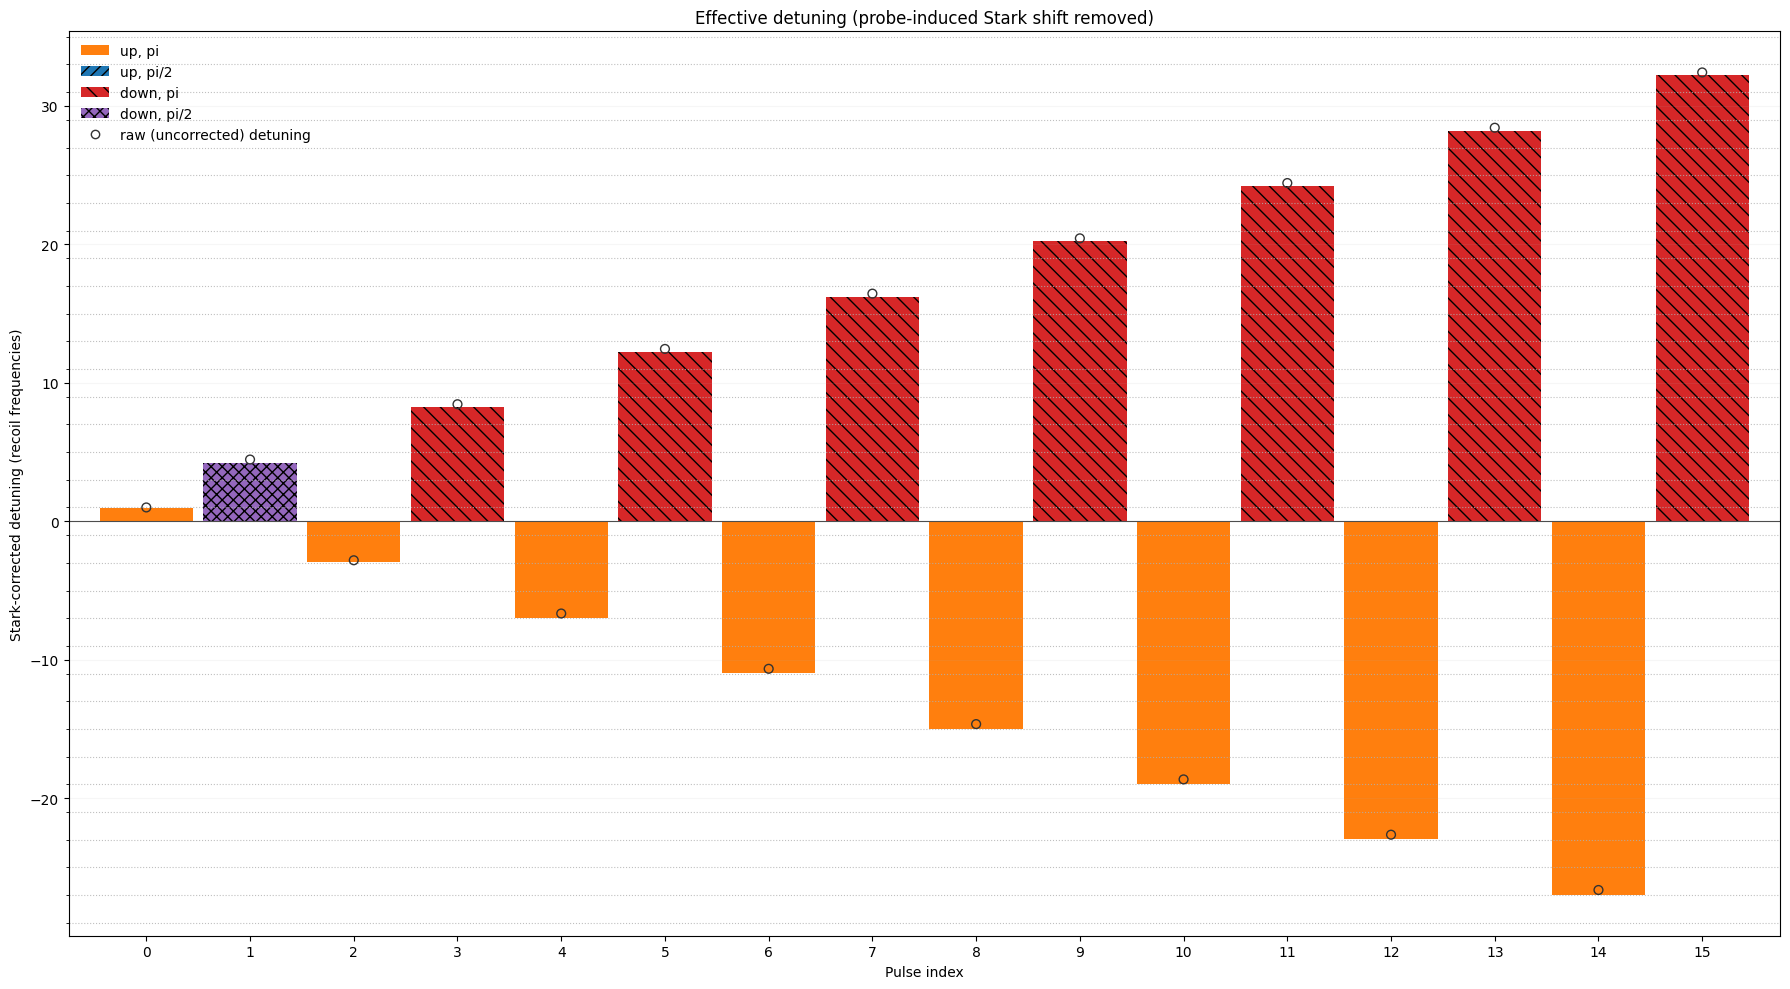

In [11]:
# Same bar plot, but with each pulse's detuning corrected for its
# probe-induced (AC-Stark) shift. The effective detuning the atom actually
# sees is detuning_hz + probe_shift_coefficient * rabi_frequency**2, so
# removing the Stark term should collapse the bars onto the clean recoil
# ladder (1, -3, 5, -7, ... in recoil units).

plot_sequence, _ = build_sequence_from_lab_pulse_dump(
    is_up=is_up,
    start_times_mu=start_times_mu,
    durations_mu=durations_mu,
    opll_hz=opll_hz,
    beam_hz=beam_hz,
)

# Truncate
plot_sequence = plot_sequence[:32]

raw_detunings_recoil = []
corrected_detunings_recoil = []
pulse_colours = []
pulse_hatches = []
clearout_links = []

last_pulse_index = None
clearout_since_last_pulse = False

PULSE_STYLES = {
    #              colour          hatch
    (True,  True):  ("tab:orange", ""),      # up,   pi
    (True,  False): ("tab:blue",   "///"),   # up,   pi/2
    (False, True):  ("tab:red",    "\\\\"),  # down, pi
    (False, False): ("tab:purple", "xxx"),   # down, pi/2
}

for event in plot_sequence:
    if isinstance(event, seq.Clearout):
        clearout_since_last_pulse = True
        continue

    if not isinstance(event, seq.Pulse):
        continue

    pulse_index = len(corrected_detunings_recoil)
    probe_shift_hz = event.probe_shift_coefficient * event.rabi_frequency**2
    raw_detunings_recoil.append(event.detuning_hz / sim.RECOIL_FREQUENCY_HZ)
    corrected_detunings_recoil.append(
        (event.detuning_hz + probe_shift_hz) / sim.RECOIL_FREQUENCY_HZ
    )
    colour, hatch = PULSE_STYLES[(event.k == 1, is_pi_pulse(event.duration))]
    pulse_colours.append(colour)
    pulse_hatches.append(hatch)

    if last_pulse_index is not None and clearout_since_last_pulse:
        clearout_links.append((last_pulse_index, pulse_index))

    last_pulse_index = pulse_index
    clearout_since_last_pulse = False

pulse_indices = np.arange(len(corrected_detunings_recoil))

fig, ax = plt.subplots(figsize=(18, 10))
bars = ax.bar(pulse_indices, corrected_detunings_recoil, color=pulse_colours, width=0.9)
for bar, hatch in zip(bars, pulse_hatches):
    bar.set_hatch(hatch)

# Show where the uncorrected (raw) detuning sat, for comparison.
ax.scatter(
    pulse_indices,
    raw_detunings_recoil,
    facecolor="none",
    edgecolor="0.2",
    marker="o",
    s=40,
    zorder=4,
)

for left_index, right_index in clearout_links:
    ax.plot(
        [left_index, right_index],
        [
            corrected_detunings_recoil[left_index],
            corrected_detunings_recoil[right_index],
        ],
        color="tab:green",
        linestyle=":",
        linewidth=2,
        zorder=3,
    )

tick_step = max(1, len(pulse_indices) // 20)
ax.set_xticks(pulse_indices[::tick_step])
ax.set_xlim(-0.75, len(pulse_indices) - 0.25)
ax.set_xlabel("Pulse index")
ax.set_ylabel("Stark-corrected detuning (recoil frequencies)")
ax.set_title("Effective detuning (probe-induced Stark shift removed)")
ax.axhline(0.0, color="0.3", linewidth=0.8)
ax.grid(axis="y", alpha=0.25)

y_min, y_max = ax.get_ylim()
odd_tick_start = int(np.floor(y_min))
if odd_tick_start % 2 == 0:
    odd_tick_start += 1
odd_tick_stop = int(np.ceil(y_max))
odd_minor_ticks = np.arange(odd_tick_start, odd_tick_stop + 1, 2)
ax.yaxis.set_minor_locator(FixedLocator(odd_minor_ticks))
ax.grid(axis="y", which="minor", linestyle=":", alpha=0.8)
ax.grid(axis="y", which="major", linestyle="-", alpha=0.1)

legend_handles = [
    Patch(facecolor="tab:orange", hatch="",     label="up, pi"),
    Patch(facecolor="tab:blue",   hatch="///",  label="up, pi/2"),
    Patch(facecolor="tab:red",    hatch="\\\\", label="down, pi"),
    Patch(facecolor="tab:purple", hatch="xxx",  label="down, pi/2"),
    Line2D([0], [0], marker="o", linestyle="none", markerfacecolor="none",
           markeredgecolor="0.2", label="raw (uncorrected) detuning"),
]
if clearout_links:
    legend_handles.append(
        Line2D(
            [0],
            [0],
            color="tab:green",
            linestyle=":",
            linewidth=2,
            label="clearout between pulses",
        )
    )

ax.legend(handles=legend_handles, loc="upper left", frameon=False)
plt.tight_layout()

plt.savefig("lab_pulse_sequence_stark_corrected.png", dpi=300)


In [12]:
(pulse_detunings_recoil[1] - pulse_detunings_recoil[0])

np.float64(3.4615237614182552)

The difference between these two should be 4 * the recoil frequency, neglecting the probe induced stark shift. The discepancy therefore gives us a check on the PSS:

In [13]:
detuning_01 = (plot_sequence[3].detuning_hz - plot_sequence[1].detuning_hz)
residual_detuning = detuning_01 - 4*sim.RECOIL_FREQUENCY_HZ
duration_0 = plot_sequence[3].duration
duration_1 = plot_sequence[1].duration

rabi_freq_0 = 1 / (4*duration_0)  # this is a pi/2
rabi_freq_1 = 1 / (2*duration_1)  # this is a pi

alpha = residual_detuning / (rabi_freq_1 **2 - rabi_freq_0 **2)
alpha

np.float64(4.8431261757732423e-05)

In [14]:
150 /(1/45e-6)**2

3.0375e-07

In [15]:
(pulse_detunings_recoil[3] - pulse_detunings_recoil[1])

np.float64(3.994521310446313)

In [16]:
(pulse_detunings_recoil[5] - pulse_detunings_recoil[3])

np.float64(3.9944654115317046)

In [17]:
(pulse_detunings_recoil[7] - pulse_detunings_recoil[5])

np.float64(3.994465411531703)

In [18]:
(pulse_detunings_recoil[9] - pulse_detunings_recoil[7])

np.float64(3.994465411519041)

In [19]:
(pulse_detunings_recoil[2] - pulse_detunings_recoil[0])

np.float64(-3.81520454283052)

In [20]:
(pulse_detunings_recoil[4] - pulse_detunings_recoil[2])

np.float64(-3.84556758102724)

In [21]:
(pulse_detunings_recoil[6] - pulse_detunings_recoil[4])

np.float64(-3.994465411519041)

In [22]:
(pulse_detunings_recoil[8] - pulse_detunings_recoil[6])

np.float64(-3.994465411531703)

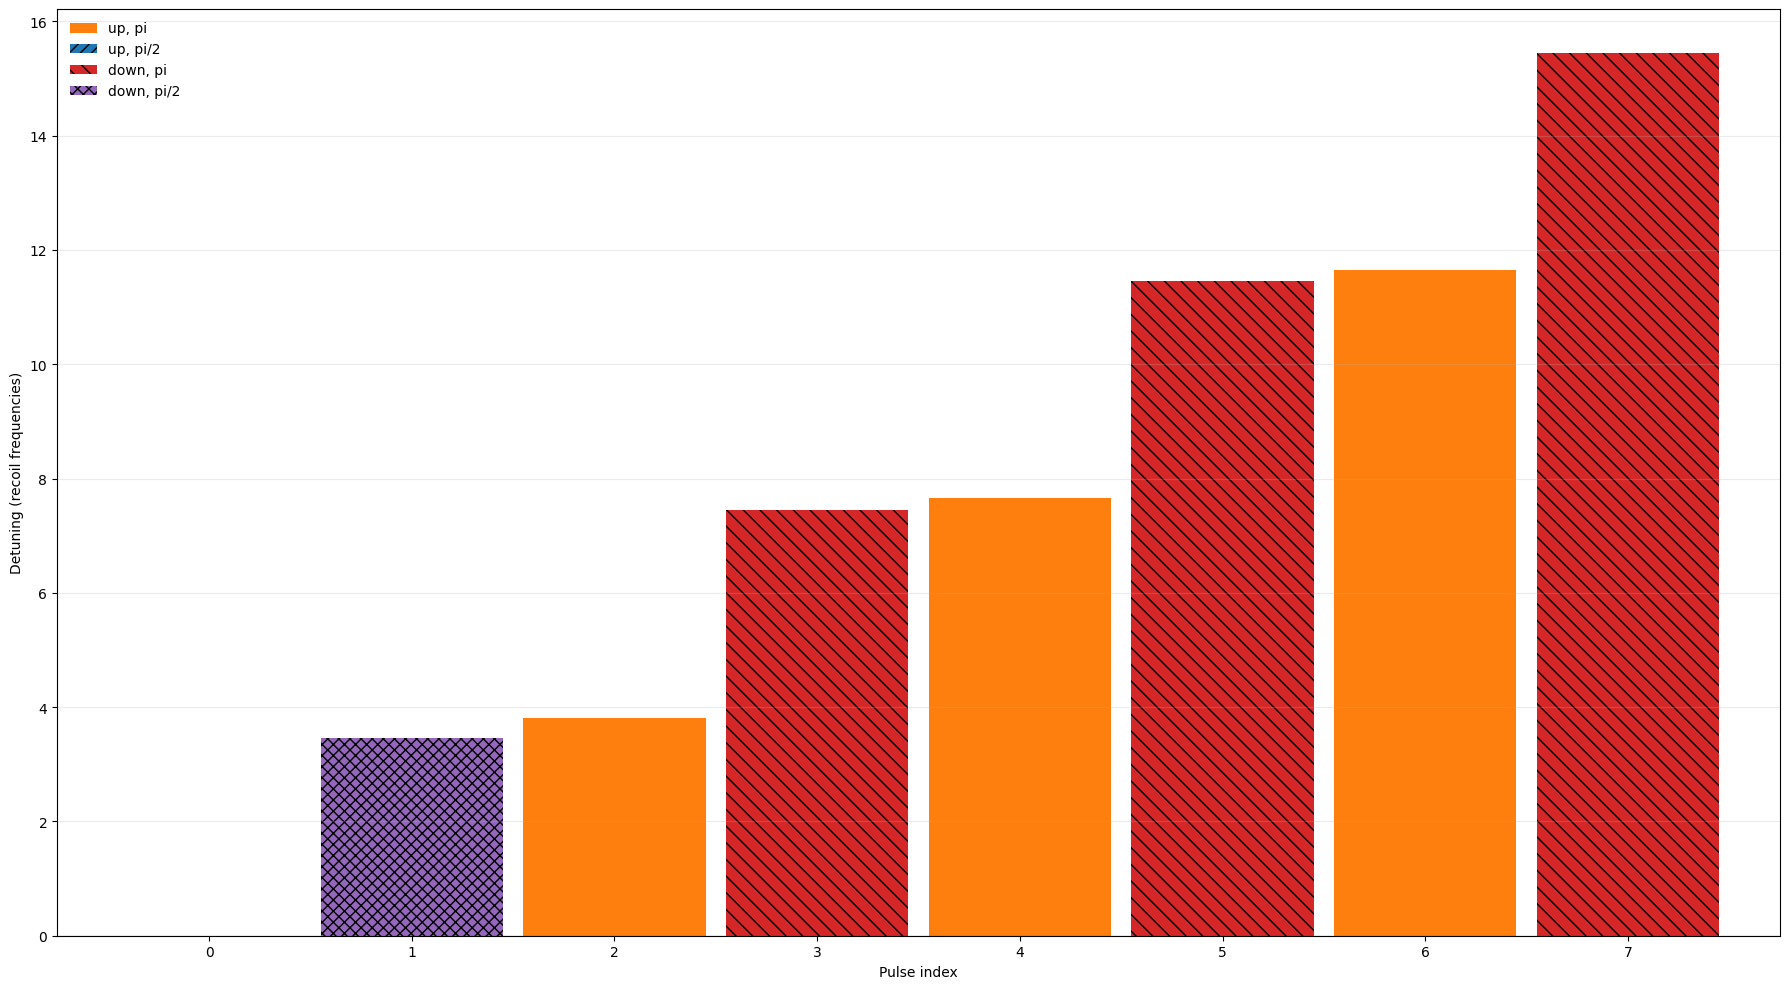

In [23]:

from matplotlib.lines import Line2D
from matplotlib.patches import Patch

plot_sequence, _ = build_sequence_from_lab_pulse_dump(
    is_up=is_up,
    start_times_mu=start_times_mu,
    durations_mu=durations_mu,
    opll_hz=opll_hz,
    beam_hz=beam_hz,
)
# plot_sequence = add_true_lmt_clearouts(plot_sequence[1:])

# Truncate
plot_sequence = plot_sequence[:16]

pulse_detunings_recoil = []
pulse_colours = []
pulse_hatches = []
clearout_links = []

last_pulse_index = None
clearout_since_last_pulse = False

reference_detuning = None

PULSE_STYLES = {
    #              colour          hatch
    (True,  True):  ("tab:orange", ""),      # up,   pi
    (True,  False): ("tab:blue",   "///"),   # up,   pi/2
    (False, True):  ("tab:red",    "\\\\"),  # down, pi
    (False, False): ("tab:purple", "xxx"),   # down, pi/2
}

for event in plot_sequence:
    if isinstance(event, seq.Clearout):
        clearout_since_last_pulse = True
        continue

    if not isinstance(event, seq.Pulse):
        continue

    if reference_detuning is None:
        reference_detuning = event.detuning_hz

    pulse_index = len(pulse_detunings_recoil)
    pulse_detunings_recoil.append(np.abs(event.detuning_hz - reference_detuning) / sim.RECOIL_FREQUENCY_HZ)
    colour, hatch = PULSE_STYLES[(event.k == 1, is_pi_pulse(event.duration))]
    pulse_colours.append(colour)
    pulse_hatches.append(hatch)

    if last_pulse_index is not None and clearout_since_last_pulse:
        clearout_links.append((last_pulse_index, pulse_index))

    last_pulse_index = pulse_index
    clearout_since_last_pulse = False

pulse_indices = np.arange(len(pulse_detunings_recoil))

fig, ax = plt.subplots(figsize=(18, 10))
bars = ax.bar(pulse_indices, pulse_detunings_recoil, color=pulse_colours, width=0.9)
for bar, hatch in zip(bars, pulse_hatches):
    bar.set_hatch(hatch)

for left_index, right_index in clearout_links:
    ax.plot(
        [left_index, right_index],
        [
            pulse_detunings_recoil[left_index],
            pulse_detunings_recoil[right_index],
        ],
        color="tab:green",
        linestyle=":",
        linewidth=2,
        zorder=3,
    )

tick_step = max(1, len(pulse_indices) // 20)
ax.set_xticks(pulse_indices[::tick_step])
ax.set_xlim(-0.75, len(pulse_indices) - 0.25)
ax.set_xlabel("Pulse index")
ax.set_ylabel("Detuning (recoil frequencies)")
ax.axhline(0.0, color="0.3", linewidth=0.8)
ax.grid(axis="y", alpha=0.25)

legend_handles = [
    Patch(facecolor="tab:orange", hatch="",     label="up, pi"),
    Patch(facecolor="tab:blue",   hatch="///",  label="up, pi/2"),
    Patch(facecolor="tab:red",    hatch="\\\\", label="down, pi"),
    Patch(facecolor="tab:purple", hatch="xxx",  label="down, pi/2"),
]
if clearout_links:
    legend_handles.append(
        Line2D(
            [0],
            [0],
            color="tab:green",
            linestyle=":",
            linewidth=2,
            label="clearout between pulses",
        )
    )

ax.legend(handles=legend_handles, loc="upper left", frameon=False)
plt.tight_layout()

plt.savefig("lab_pulse_sequence.png", dpi=300)


In [24]:
 (sim.RECOIL_FREQUENCY_HZ * 2 - 9400 ) * 30

421.7164782765576

In [25]:
421 / (1 / 55e-6)

0.023155000000000002

([compute_spacetime_trajectory.<locals>.Cloud(times=[0.0, np.float64(0.00038), np.float64(0.002685463), np.float64(0.002719463), np.float64(0.00277824), np.float64(0.00287324), np.float64(0.002979088), np.float64(0.003047088), np.float64(0.003107088), np.float64(0.003162087), np.float64(0.003222088), np.float64(0.003290088), np.float64(0.003350088), np.float64(0.0034050870000000002), np.float64(0.0034650880000000003), np.float64(0.003533088), np.float64(0.003593088), np.float64(0.003648087), np.float64(0.003708088), np.float64(0.003776088), np.float64(0.003836088), np.float64(0.003891087), np.float64(0.003951088), np.float64(0.0040190880000000005), np.float64(0.004079088000000001), np.float64(0.004134087000000001), np.float64(0.004194088), np.float64(0.004262088000000001), np.float64(0.004322088000000001), np.float64(0.004377087000000001), np.float64(0.0044370880000000005), np.float64(0.004505088000000001), np.float64(0.004565088000000001), np.float64(0.004620087000000001), np.float64(

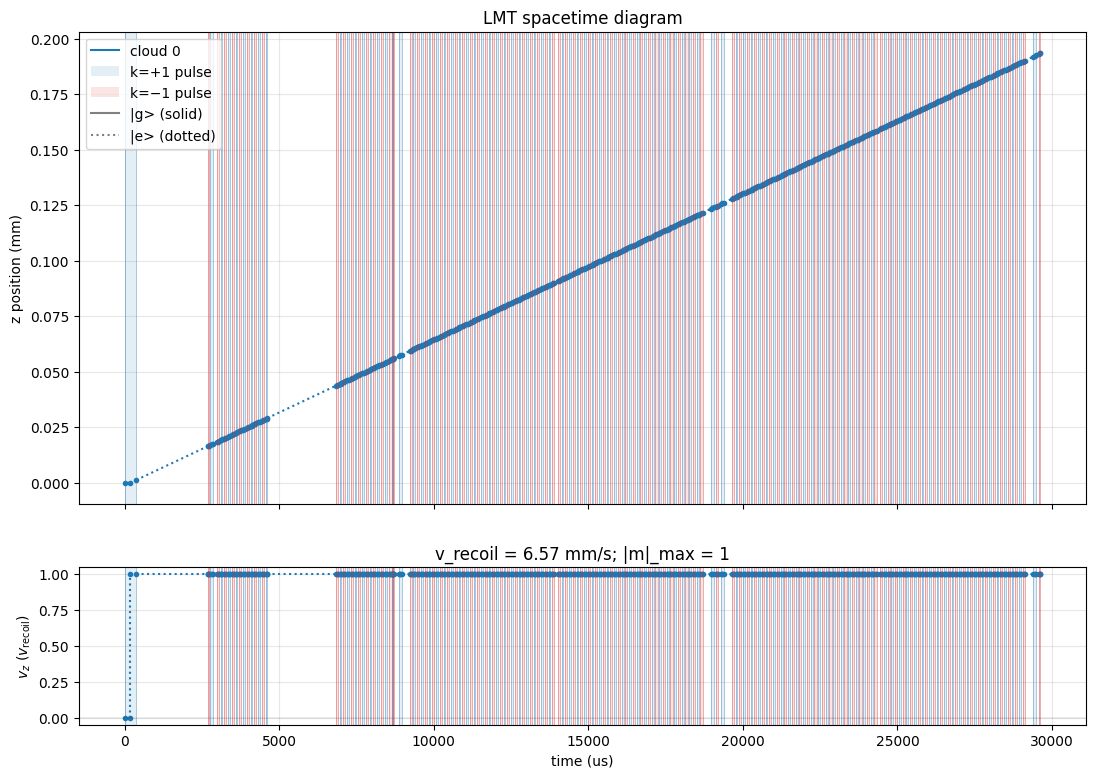

In [26]:
seq.compute_spacetime_trajectory(sequence, plot=True, max_branches=20)


In [27]:
sequence

[Pulse(k=1, detuning_hz=np.float64(4707.028607964516), phi=0.0, label='LMT', rabi_frequency=np.float64(1315.7894736842104), duration=np.float64(0.00038), beam_waist=1000000.0, probe_shift_coefficient=-1.9e-05),
 Freefall(duration=np.float64(0.002305463), label='freefall'),
 Pulse(k=-1, detuning_hz=np.float64(21000.51998013258), phi=0.0, label='LMT', rabi_frequency=np.float64(7352.941176470588), duration=np.float64(3.4e-05), beam_waist=1000000.0, probe_shift_coefficient=-1.9e-05),
 Freefall(duration=np.float64(5.8776999999999874e-05), label='freefall'),
 Pulse(k=1, detuning_hz=np.float64(-13251.248320400715), phi=0.0, label='LMT', rabi_frequency=np.float64(5263.157894736842), duration=np.float64(9.5e-05), beam_waist=1000000.0, probe_shift_coefficient=-1.9e-05),
 Freefall(duration=np.float64(0.00010584799999999997), label='freefall'),
 Pulse(k=-1, detuning_hz=np.float64(39802.84606355429), phi=0.0, label='LMT', rabi_frequency=np.float64(7352.941176470588), duration=np.float64(6.8e-05), b